# Flight Delay Prediction Using Machine Learning

Client: Airline company  
Objective: Train classification models to predict whether a flight will be delayed or on time.

## 1. Import Libraries and Load Project Code

In [1]:
from pathlib import Path
import sys
import pandas as pd
import joblib
from IPython.display import Image, display, Markdown

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_DIR / 'src'))

from train_model import (
    DATA_PATH,
    MODEL_PATH,
    REPORT_PATH,
    FIGURE_DIR,
    load_and_prepare_data,
    build_preprocessor,
    get_models,
    evaluate_model,
    save_figures,
    write_report,
    RANDOM_STATE,
)
from sklearn.model_selection import train_test_split

DATA_PATH

WindowsPath('E:/Pythoon for DataSCIENCES/Flight_Delay_Prediction_Project/data/raw/Airlines.csv')

## 2. Data Preparation

- Drop columns with too many missing values
- Encode Airline and route columns using OneHotEncoder
- Convert FlightDate to weekday and month when available
- Use the existing DayOfWeek column for this dataset

In [2]:
raw_df = pd.read_csv(DATA_PATH)
raw_df.head()

,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


In [3]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539383 entries, 0 to 539382
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           539383 non-null  int64 
 1   Airline      539383 non-null  object
 2   Flight       539383 non-null  int64 
 3   AirportFrom  539383 non-null  object
 4   AirportTo    539383 non-null  object
 5   DayOfWeek    539383 non-null  int64 
 6   Time         539383 non-null  int64 
 7   Length       539383 non-null  int64 
 8   Delay        539383 non-null  int64 
dtypes: int64(6), object(3)
memory usage: 37.0+ MB


In [4]:
x, y = load_and_prepare_data(DATA_PATH)
print('Features shape:', x.shape)
print('Target distribution:')
print(y.value_counts(normalize=True).rename({0: 'On Time', 1: 'Delayed'}))
x.head()

Features shape: (539383, 6)
Target distribution:
Delay
On Time    0.554558
Delayed    0.445442
Name: proportion, dtype: float64


,Airline,AirportFrom,AirportTo,DayOfWeek,Time,Length
0,CO,SFO,IAH,3,15,205
1,US,PHX,CLT,3,15,222
2,AA,LAX,DFW,3,20,165
3,AA,SFO,DFW,3,20,195
4,AS,ANC,SEA,3,30,202


## 3. Train/Test Split

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

x_train.shape, x_test.shape

((431506, 6), (107877, 6))

## 4. Model Building

Train Logistic Regression and Random Forest models.

In [6]:
preprocessor = build_preprocessor(x)
models = get_models(preprocessor)
metrics = {}

for model_name, model in models.items():
    print(f'Training {model_name}...')
    model.fit(x_train, y_train)
    metrics[model_name] = evaluate_model(model, x_test, y_test)
    print(
        model_name,
        'Accuracy:', round(metrics[model_name]['accuracy'], 4),
        'Precision:', round(metrics[model_name]['precision'], 4),
        'Recall:', round(metrics[model_name]['recall'], 4),
        'ROC AUC:', round(metrics[model_name]['roc_auc'], 4),
    )

Training Logistic Regression...


Logistic Regression Accuracy: 0.639 Precision: 0.5943 Recall: 0.5974 ROC AUC: 0.6915
Training Random Forest...


Random Forest Accuracy: 0.6473 Precision: 0.6144 Recall: 0.5592 ROC AUC: 0.7007


## 5. Evaluation

In [7]:
results = pd.DataFrame([
    {
        'Model': model_name,
        'Accuracy': values['accuracy'],
        'Precision': values['precision'],
        'Recall': values['recall'],
        'ROC AUC': values['roc_auc'],
    }
    for model_name, values in metrics.items()
]).sort_values('ROC AUC', ascending=False)

results

,Model,Accuracy,Precision,Recall,ROC AUC
1,Random Forest,0.647330,0.614409,0.559237,0.700696
0,Logistic Regression,0.639006,0.594306,0.597361,0.691527


In [8]:
best_model_name = results.iloc[0]['Model']
best_model = models[best_model_name]
print('Best model:', best_model_name)
print(metrics[best_model_name]['classification_report'])

Best model: Random Forest
              precision    recall  f1-score   support

           0       0.67      0.72      0.69     59824
           1       0.61      0.56      0.59     48053

    accuracy                           0.65    107877
   macro avg       0.64      0.64      0.64    107877
weighted avg       0.65      0.65      0.65    107877



In [9]:
joblib.dump(best_model, MODEL_PATH)
save_figures(best_model, x_test, y_test)
write_report(metrics, best_model_name, x, y)

print('Saved model:', MODEL_PATH)
print('Saved report:', REPORT_PATH)

Saved model: E:\Pythoon for DataSCIENCES\Flight_Delay_Prediction_Project\models\flight_delay_best_model.pkl
Saved report: E:\Pythoon for DataSCIENCES\Flight_Delay_Prediction_Project\reports\model_evaluation_report.md


<Figure size 700x500 with 0 Axes>

## 6. Confusion Matrix and ROC Curve

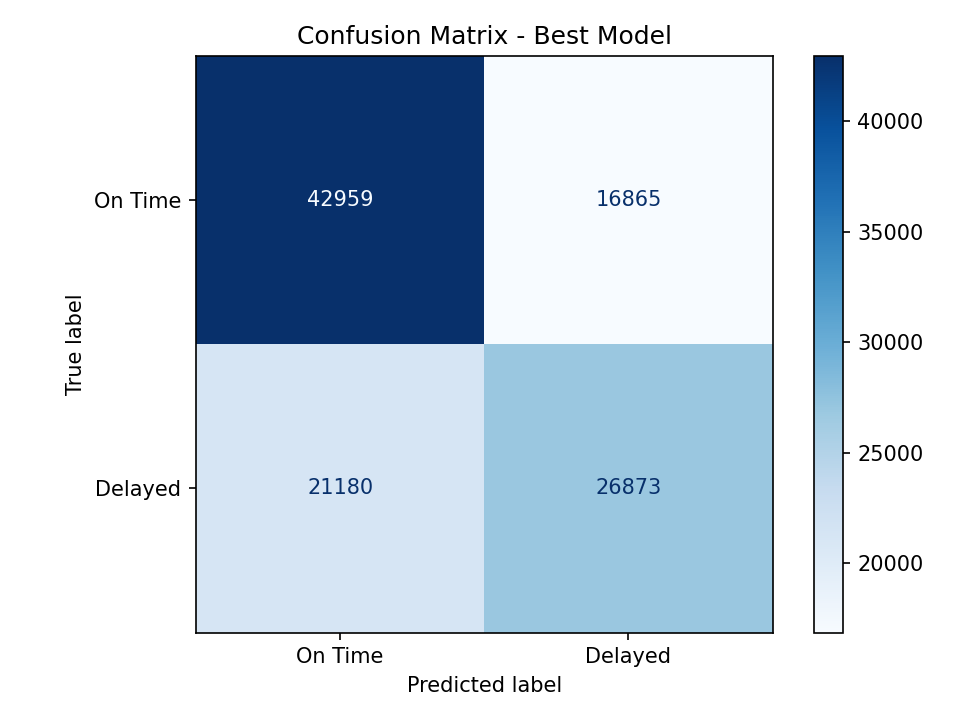

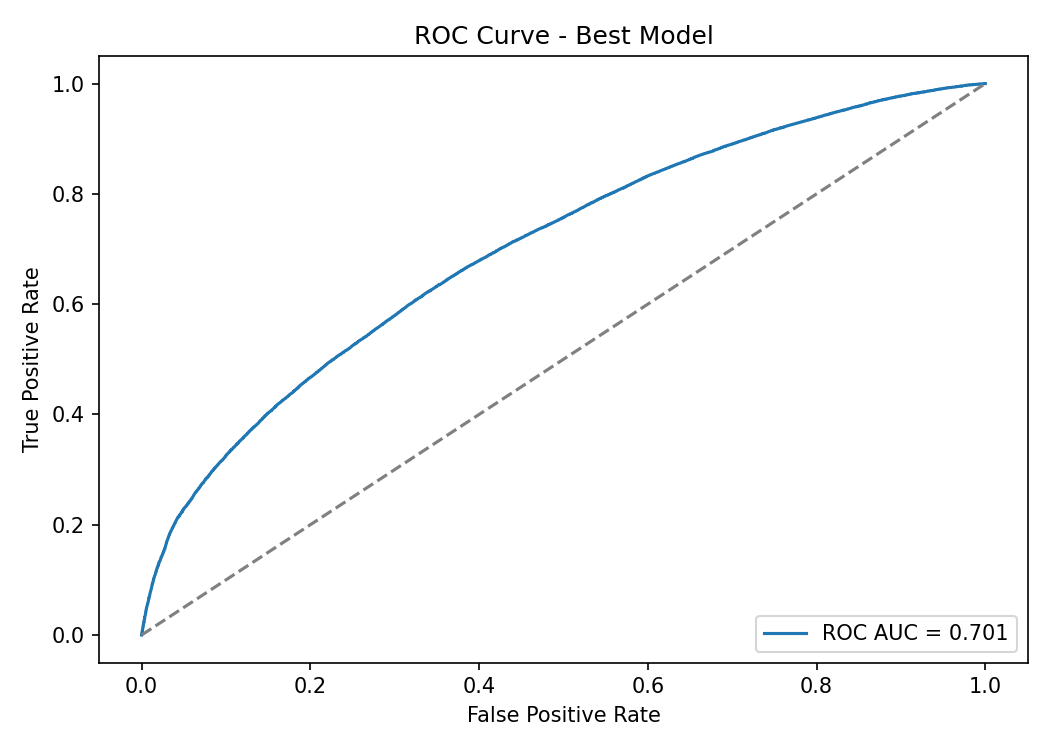

In [10]:
display(Image(filename=str(FIGURE_DIR / 'confusion_matrix.png')))
display(Image(filename=str(FIGURE_DIR / 'roc_curve.png')))

## 7. Model Evaluation Report

In [11]:
display(Markdown(REPORT_PATH.read_text(encoding='utf-8')))

# Flight Delay Prediction - Model Evaluation Report

## Project Objective
Predict whether a flight will be delayed or on time using airline, route, and flight schedule data.

## Dataset Summary
- Source file: `data/raw/Airlines.csv`
- Total rows after cleaning duplicates: 539,383
- Feature columns used: 6
- Target column: `Delay`
- On-time records: 299,119
- Delayed records: 240,264

## Preprocessing
- Dropped columns with more than 45% missing values.
- Converted `FlightDate` to weekday and month if that column exists.
- Encoded categorical route and airline columns with OneHotEncoder.
- Imputed missing numeric values with median and categorical values with most frequent value.
- Dropped ID-like columns: `id`, `Flight` when present.

## Model Performance
| Model               |   Accuracy |   Precision |   Recall |   ROC AUC |
|:--------------------|-----------:|------------:|---------:|----------:|
| Logistic Regression |     0.639  |      0.5943 |   0.5974 |    0.6915 |
| Random Forest       |     0.6473 |      0.6144 |   0.5592 |    0.7007 |

## Best Model
The selected model is **Random Forest**, chosen by the highest ROC AUC score.

## Best Model Confusion Matrix
```text
[[42959, 16865], [21180, 26873]]
```

## Best Model Classification Report
```text
              precision    recall  f1-score   support

           0       0.67      0.72      0.69     59824
           1       0.61      0.56      0.59     48053

    accuracy                           0.65    107877
   macro avg       0.64      0.64      0.64    107877
weighted avg       0.65      0.65      0.65    107877

```

## Generated Files
- Saved model: `models/flight_delay_best_model.pkl`
- Metrics JSON: `reports/metrics.json`
- Confusion matrix: `reports/figures/confusion_matrix.png`
- ROC curve: `reports/figures/roc_curve.png`
